# 2D Transpose Convolution

In [ ]:
# La 2D TRANSPOSE CONVOLUTION è un'operazione learnable che aumenta la risoluzione spaziale
# Il contrario della convoluzione: ogni scalare dell'input viene espanso dal kernel 
# su una regione dell'output e le regioni sovrapposte vengono sommate

In [3]:
import torch
import random
import matplotlib.pyplot as plt

In [86]:
# Set-up code
n = random.randint(2, 6)
iC = random.randint(2, 6)
oC = random.randint(2, 6)
H = random.randint(10, 20)
W = random.randint(10, 20)
kH = random.randint(2, 6)
kW = random.randint(2, 6)
s = random.randint(2, 6)

input = torch.rand(n, iC, H, W)
kernel = torch.rand(iC, oC, kH, kW)

#### Single Step Logic

In [87]:
# input shape: (n, iC, H, W)
print("input shape:", input.shape)

# kernel shape: (iC, oC, kH, kW) --> iC e oC sono invertiti!!
print("kernel shape:", kernel.shape)

# stride
print("stride:", s)

input shape: torch.Size([3, 3, 19, 14])
kernel shape: torch.Size([3, 5, 2, 3])
stride: 3


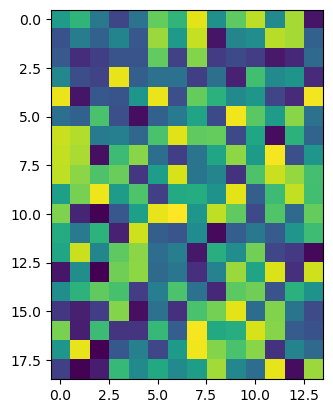

In [88]:
# INPUT
plt.imshow(input[0, 0].numpy())

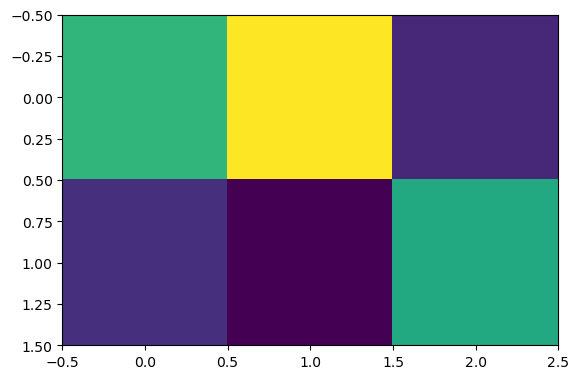

In [89]:
# KERNEL
plt.imshow(kernel[0, 0].numpy())

In [90]:
# unsqueeze a 2 perché oC e iC sono invertiti nel kernel
input.unsqueeze_(2)
kernel.unsqueeze_(0)


# input shape: (n, iC, 1, H, W)
print("input shape:", input.shape)

# kernel shape: (1, iC, oC, kH, kW)
print("kernel shape:", kernel.shape)

input shape: torch.Size([3, 3, 1, 19, 14])
kernel shape: torch.Size([1, 3, 5, 2, 3])


In [91]:
padding = 0
dilation = 1

oH = (H-1)*s -2*padding + dilation*(kH-1) + 1
oW = (W-1)*s -2*padding + dilation*(kW-1) + 1

out = torch.zeros(n, oC, oH, oW)

# output shape: (n, oC, oH, oW)
print("out shape:", out.shape)

out shape: torch.Size([3, 5, 56, 42])


In [92]:
# Meccanismo "scatter-add"
for r in range(H):
    for c in range(W):
        # scalare x vettore "mangia" una dimensione --> la convenzione è fare r:r+1 e c:c+1 oppure l'unsqueeze alla fine
        out[..., r*s:r*s+kH, c*s:c*s+kW] += (input[..., r:r+1, c:c+1] * kernel).sum(dim=1)


# Scalare x vettore "mangia" una dimensione 
# --> la convenzione è fare r:r+1 e c:c+1 oppure l'unsqueeze alla fine
 
# RAGIONAMENTO BROADCASTING NEI CICLI:
# input  --> (n, iC,  1,  1,  1)
# kernel --> (1, iC, oC, kH, kW)
# -------------------------------
# BC     --> (n, iC, oC, kH, kW)
#
# sum(dim=1) --> somma su tutti gli iC (collassa la dimensione) --> si adatta alla shape di out
#
# out[...] --> (n, oC, kH, kW)

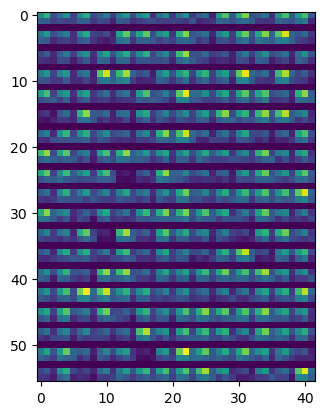

In [93]:
# OUTPUT
plt.imshow(out[0, 0].numpy())

#### 2D Transposed Convolution Function

In [106]:
def transposed_convolution(input, kernel, stride, padding=0, dilation=1):
    
    if(kernel.ndim == 4):
        kernel.unsqueeze_(0)
        
    if(input.ndim == 4):
        input.unsqueeze_(2)
    
    oH = (H-1)*stride -2*padding + dilation*(kH-1) + 1
    oW = (W-1)*stride -2*padding + dilation*(kW-1) + 1

    out = torch.zeros(n, oC, oH, oW)
    
    for r in range(H):
        for c in range(W):
            out[..., r*s:r*s+kH, c*s:c*s+kW] += (input[..., r:r+1, c:c+1] * kernel).sum(dim=1)
    
    return out

#### Real Image Testing

In [95]:
import numpy as np
from PIL import Image

In [98]:
image = Image.open('lenna.jpg')

In [99]:
# INPUT PRE-PROCESSING
image = torch.from_numpy(np.array(image, dtype=np.float32)).permute(2, 0, 1)
image = image.unsqueeze(0)
image = image.to(torch.float32)

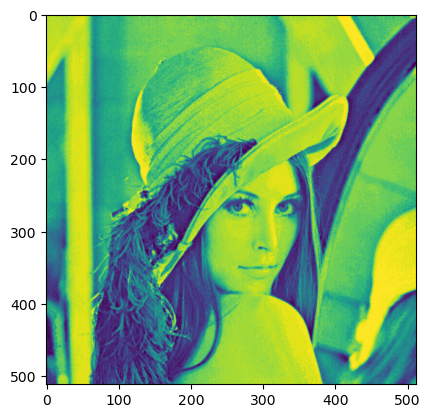

In [100]:
# INPUT
plt.imshow(image[0, 0].numpy())

In [107]:
output = transposed_convolution(image, kernel, s)

In [108]:
# output shape: (n, oC, oH, oW)
print("output shape:", output.shape)

output shape: torch.Size([3, 5, 56, 42])


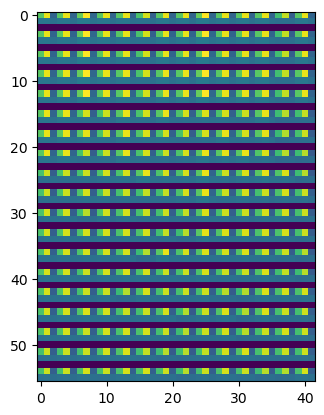

In [109]:
# OUTPUT
plt.imshow(output[0, 0].numpy())